#  The Diabetes Detective: A Data Science Investigation

By the end of this notebook, I would have:

1.  **Cleaned** messy real-world data
2.  **Explored** it with charts that actually tell a story
3.  **Built a Simple Linear Regression** model (one predictor, one target)
4.  **Built a Multiple Linear Regression** model (several predictors at once)
5.  **Built a Logistic Regression classifier** to actually predict diabetes
6.  **Compared everything** and drawn real conclusions

In [1]:
# ===============================
# Import needed libraries
# ===============================

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.ensemble import RandomForestClassifier
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Cool plotting
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

In [2]:
# Load Dataset

path = r"C:\Users\EHU_HEALTH_TECHNICAL\Documents\Khing_FM_Data_Science\Data_Science\assets\ts-academy_datasets\diabetes.csv"

df = pd.read_csv(path)

# Dataset Exploration

In [3]:
# Explore Dataset

print(f"Shape: {df.shape[0]} patients, {df.shape[1]} columns")
df.head()

Shape: 768 patients, 9 columns


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


**First impressions:**
- We have **768 patients** and **9 columns** (8 features + 1 target: `Outcome`).
- `Outcome` is our target: `1` = diabetic, `0` = not diabetic.
- No `NaN` values show up in `.info()` — but the `min` column in the table above: `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` all have a **minimum of 0**. A living patient cannot have a blood pressure of zero. These are *missing values in disguise* — Unmasking them later


## Data Cleaning

Real-world data is never clean out of the box. Here, missing values weren't left blank — they were recorded as `0`, which is medically impossible for columns like `Glucose` or `BMI`. Let's expose them.


In [6]:
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_counts = (df[zero_cols] == 0).sum()
zero_pct = (zero_counts / len(df) * 100).round(1)

hidden_missing = pd.DataFrame({"Zero Count": zero_counts, "% of Data": zero_pct})
hidden_missing

,Zero Count,% of Data
Glucose,5,0.7
BloodPressure,35,4.6
SkinThickness,227,29.6
Insulin,374,48.7
BMI,11,1.4


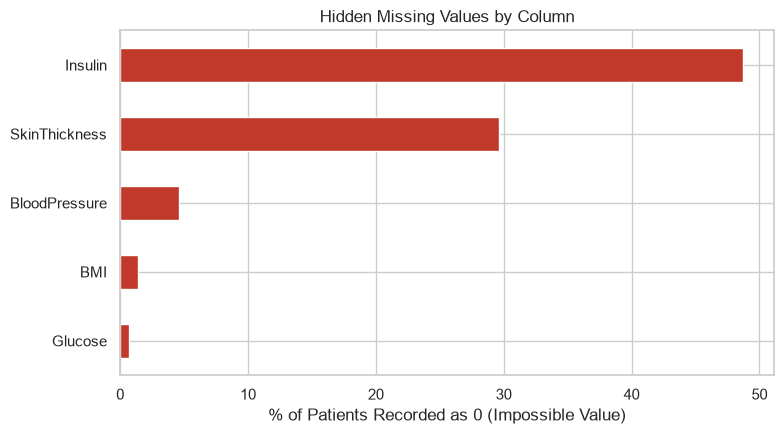

In [7]:
# Lets view the missing values by plotting

fig, ax = plt.subplots(figsize=(8, 4.5))
hidden_missing["% of Data"].sort_values().plot(kind="barh", color="#c0392b", ax=ax)
ax.set_xlabel("% of Patients Recorded as 0 (Impossible Value)")
ax.set_title("Hidden Missing Values by Column")
plt.tight_layout()
plt.show()

`Insulin` is missing (as 0) for nearly half the patients, and `SkinThickness` for about 30%. If we trained a model on these raw zeros, it would learn nonsense (e.g., "0 insulin patients are healthier").

**The fix:** Replace these disguised zeros with `NaN`, then impute them using the **median** of each column (median is robust to outliers, unlike the mean). We'll impute per `Outcome` group so the imputation doesn't blur the difference between diabetic and non-diabetic patients.


In [8]:
df_clean = df.copy()
df_clean[zero_cols] = df_clean[zero_cols].replace(0, np.nan)

print("Missing values before imputation:")
print(df_clean[zero_cols].isna().sum())

# Impute with the median within each outcome group (0 or 1)
for col in zero_cols:
    df_clean[col] = df_clean.groupby("Outcome")[col].transform(
        lambda x: x.fillna(x.median())
    )

    print("\nMissing values after imputation:")
    print(df_clean[zero_cols].isna().sum())

Missing values before imputation:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Missing values after imputation:
Glucose            0
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Missing values after imputation:
Glucose            0
BloodPressure      0
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Missing values after imputation:
Glucose            0
BloodPressure      0
SkinThickness      0
Insulin          374
BMI               11
dtype: int64

Missing values after imputation:
Glucose           0
BloodPressure     0
SkinThickness     0
Insulin           0
BMI              11
dtype: int64

Missing values after imputation:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


## Exploratory Data Analysis (EDA)

Time to let the data talk. We're looking for patterns, imbalances, and relationships before we build a single model.

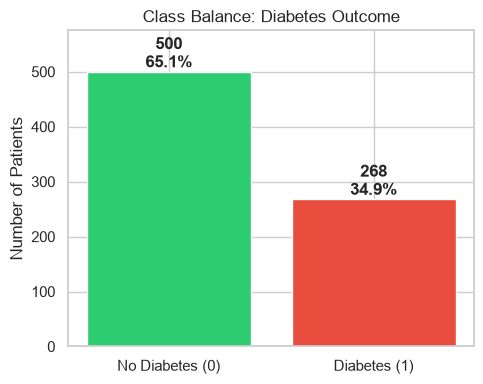

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df_clean["Outcome"].value_counts().sort_index()
labels = ["No Diabetes (0)", "Diabetes (1)"]
colors = ["#2ecc71", "#e74c3c"]
ax.bar(labels, counts.values, color=colors)
for i, v in enumerate(counts.values):
    ax.text(i, v + 8, f"{v}\n{v/len(df_clean)*100:.1f}%", ha="center", fontweight="bold")
ax.set_ylim(0, counts.max() * 1.15)
ax.set_title("Class Balance: Diabetes Outcome")
ax.set_ylabel("Number of Patients")
plt.tight_layout()
plt.show()

About **65% negative, 35% positive** — not perfectly balanced, but not extreme either. Good to know before we judge model accuracy later (a model that always guesses "no diabetes" would already be ~65% "accurate" — so we'll need better metrics than accuracy alone).

# DISTRIBUTION FOR EVERY FEATURE

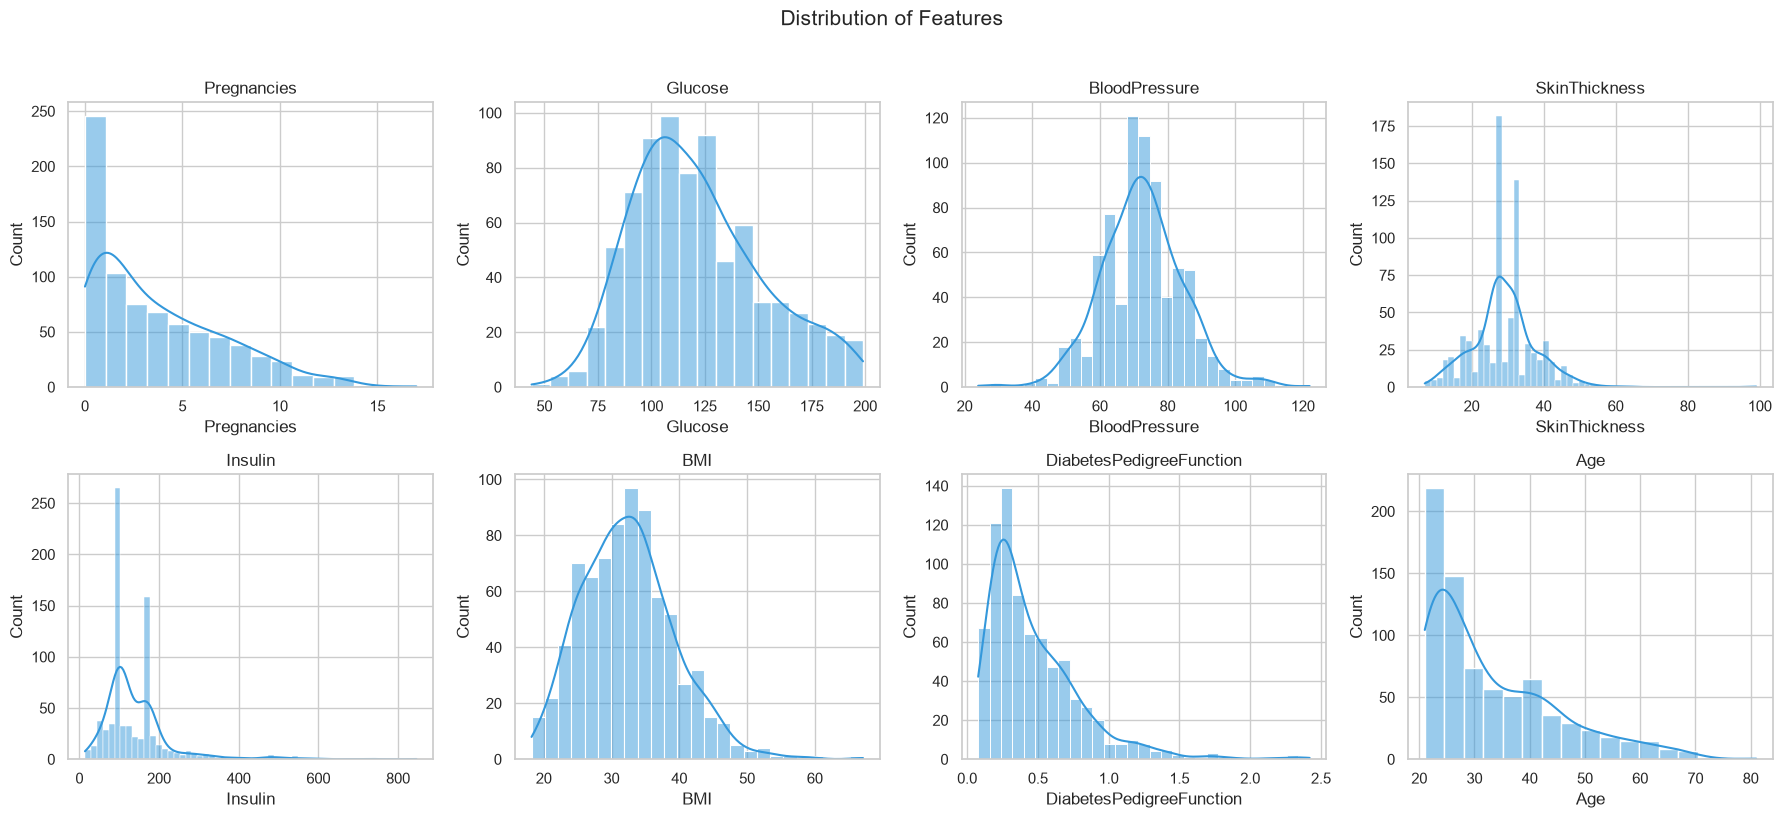

In [10]:
features = [c for c in df_clean.columns if c != "Outcome"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color="#3498db")
    axes[i].set_title(col)
plt.suptitle("Distribution of Features", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# Differences in features between diabetic and non diabetic patients

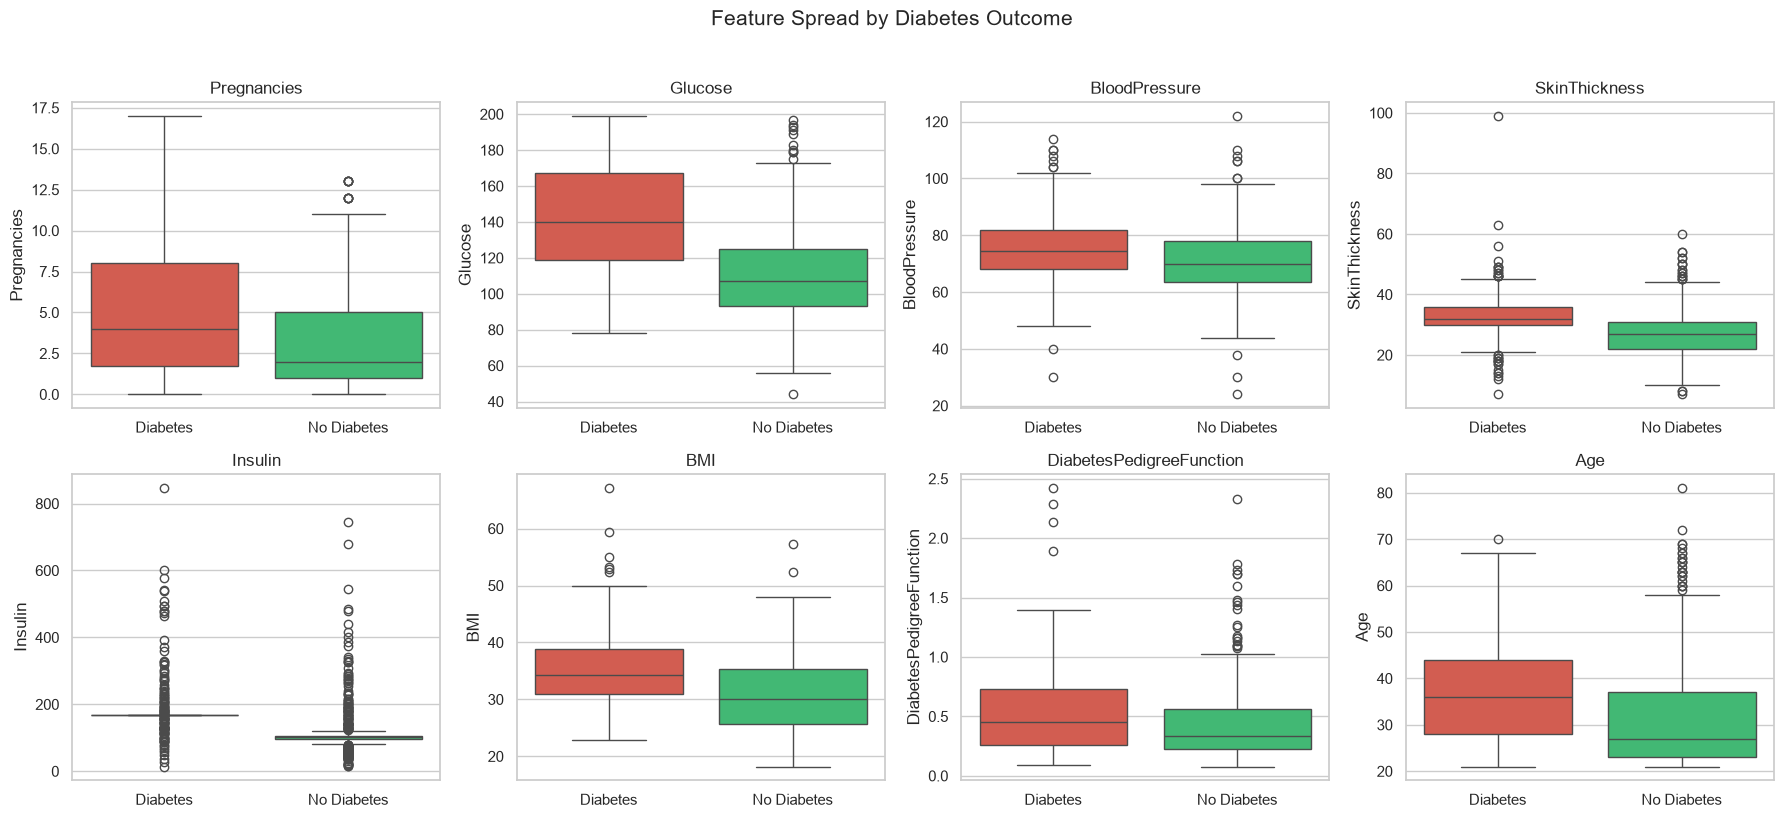

In [11]:
plot_data = df_clean.copy()
plot_data["Outcome Label"] = plot_data["Outcome"].map({0: "No Diabetes", 1: "Diabetes"})

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.boxplot(
        x="Outcome Label",
        y=col,
        data=plot_data,
        hue="Outcome Label",
        palette={"No Diabetes": colors[0], "Diabetes": colors[1]},
        legend=False,
        ax=axes[i],
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("")
plt.suptitle("Feature Spread by Diabetes Outcome", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# Correlation Heatmap

In [ ]:
corr = df_clean.corr()
fig, ax = plt.subplots(figsize=(9, 7))
